In [28]:
import sys, importlib
import pandas as pd
sys.path.append('/mnt/jack-5/amismailov/miRNA_study')
import bootstrap
importlib.reload(bootstrap)
from bootstrap import Bootstrap

In [29]:
path_mrna = '/mnt/jack-5/amismailov/miRNA_study/single_cell/mRNA_counts.csv'
path_mir = '/mnt/jack-5/amismailov/miRNA_study/single_cell/miRNA_counts.csv'
path_length = '/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet'
shared_rna = '/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/shared_features_v2.txt'
targets = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/learning/targets.csv', index_col=0)['miR'].tolist()
path_barcodes = '/mnt/jack-5/amismailov/miRNA_study/single_cell/barcodes_combined_filtered.csv' 


boot = Bootstrap(path_mrna, path_mir, path_barcodes, path_length, selected_rna_path=shared_rna, selected_mirs=targets)

Loading data...
Preprocessing miRNAs...
Ready. Cells: 2310, Tissues: 4


In [30]:
boot.get_tissues()

['293T-MS', 'A549-MS', 'HELA-MS', 'K562-MS']

In [31]:
ctr = 0
for tissue in boot.get_tissues():
    ctr += len(boot.get_tissue_barcodes(tissue))
ctr

2310

In [38]:
boot.generate(tissue='293T-MS', K=2, N=10,subset_barcodes=boot.get_tissue_barcodes('293T-MS')[1:10])[0]

,boot_K2_293T-MS_0,boot_K2_293T-MS_1,boot_K2_293T-MS_2,boot_K2_293T-MS_3,boot_K2_293T-MS_4,boot_K2_293T-MS_5,boot_K2_293T-MS_6,boot_K2_293T-MS_7,boot_K2_293T-MS_8,boot_K2_293T-MS_9
Unnamed: 0,,,,,,,,,,
ENSG00000000003,6.116348,4.814515,6.161013,6.116348,0.000000,6.116348,5.887606,5.678317,5.978153,5.698622
ENSG00000000005,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419,5.019410,2.756677,3.910245,5.019410,1.929222,5.019410,3.124068,3.417478,3.696717,3.561595
ENSG00000000457,1.800732,1.309698,2.537552,1.800732,0.000000,1.800732,1.370627,2.242123,2.487988,1.916692
ENSG00000000460,0.684534,0.000000,0.000000,0.684534,0.769986,0.684534,0.828048,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
ENSG00000286224,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000286264,5.309737,5.555772,6.244254,5.309737,6.095129,5.309737,5.248898,6.611578,6.595040,5.466044
ENSG00000286920,0.000000,4.686284,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.792466,0.000000


# TRAIN TEST SPLIT

In [48]:
barcodes_dict = {}
for tissue in boot.get_tissues():
    barcodes_dict.setdefault(tissue, None)
    barcodes_dict[tissue] = list(boot.get_tissue_barcodes(tissue))
    print(f'Tissue {tissue} has {len(barcodes_dict[tissue])} barcodes')

Tissue 293T-MS has 539 barcodes
Tissue A549-MS has 625 barcodes
Tissue HELA-MS has 535 barcodes
Tissue K562-MS has 611 barcodes


In [51]:
from sklearn.model_selection import train_test_split

# Результирующий словарь
split_data = {}

SEED = 42

for tissue, barcodes in barcodes_dict.items():
    # Разделяем внутри каждой ткани
    train_b, test_b = train_test_split(
        barcodes, 
        test_size=0.20, 
        random_state=SEED,
        shuffle=True
    )
    
    split_data[tissue] = {
        'train': train_b,
        'test': test_b
    }
    
    print(f"Tissue {tissue:10} | Train: {len(train_b)} | Test: {len(test_b)}")

# Теперь у тебя есть полный контроль:
# split_data['K562-MS']['train'] — это список только для трейна K562

Tissue 293T-MS    | Train: 431 | Test: 108
Tissue A549-MS    | Train: 500 | Test: 125
Tissue HELA-MS    | Train: 428 | Test: 107
Tissue K562-MS    | Train: 488 | Test: 123


In [53]:
import pandas as pd

# 1. Собираем данные из словаря split_data в плоские списки
train_rows = []
test_rows = []

for tissue, data in split_data.items():
    # Собираем трейн
    for barcode in data['train']:
        train_rows.append({'tissue': tissue, 'barcode': barcode})
    
    # Собираем тест
    for barcode in data['test']:
        test_rows.append({'tissue': tissue, 'barcode': barcode})

# 2. Создаем DataFrame
df_train_split = pd.DataFrame(train_rows)
df_test_split = pd.DataFrame(test_rows)

# 3. Сохраняем в CSV
df_train_split.to_csv('barcodes_train_split.csv', index=False)
df_test_split.to_csv('barcodes_test_split.csv', index=False)

print(f"Файлы сохранены!")
print(f"Train split: {df_train_split.shape[0]} строк")
print(f"Test split: {df_test_split.shape[0]} строк")

Файлы сохранены!
Train split: 1847 строк
Test split: 463 строк


In [54]:
df_train_split

,tissue,barcode
0,293T-MS,CGTACGGAATGA_2
1,293T-MS,AGCGGCAGCCAA_1
2,293T-MS,AGAAGAATAGAG_2
3,293T-MS,CCGTCCATAGAG_2
4,293T-MS,ATGTCAATAGAG_2
...,...,...
1842,K562-MS,GTGAAACAGATT_1
1843,K562-MS,GTAAGAAGTCTT_1
1844,K562-MS,ACTGATCATGGC_1
1845,K562-MS,TCGCGGATGCCA_2


# Generate

Calculating variances...


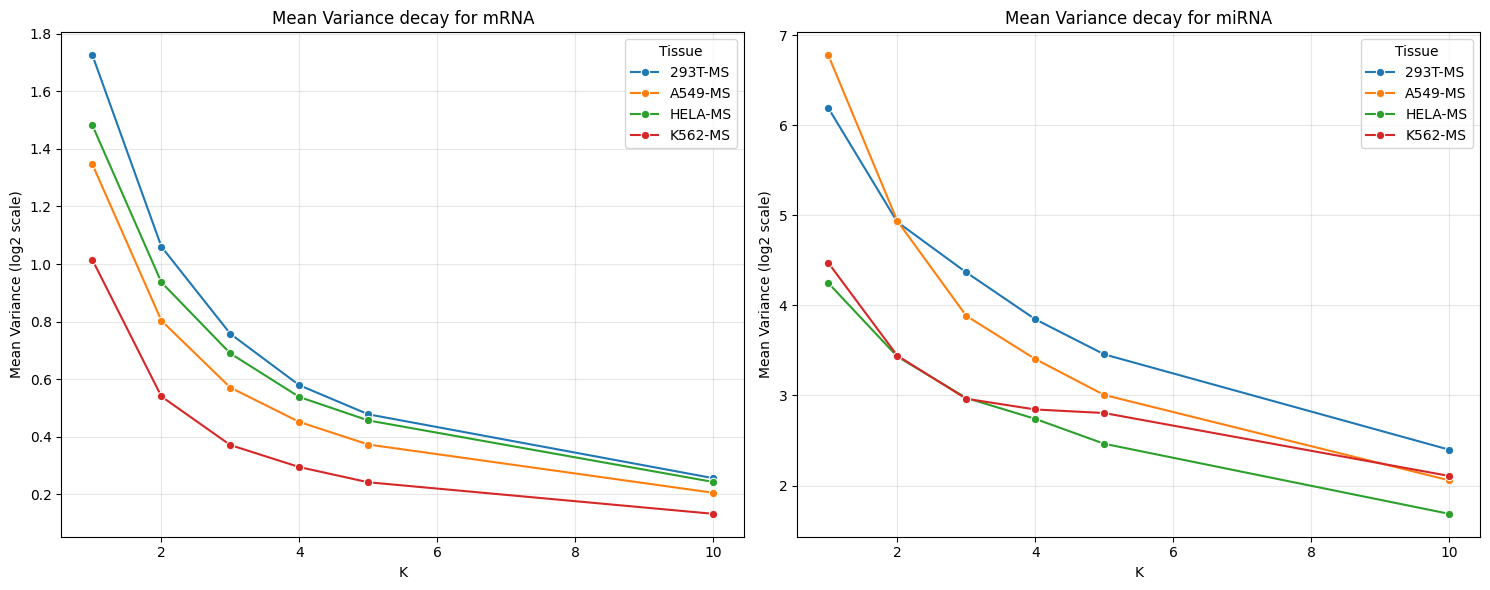

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Списки для сбора статистики
stats_rows = []

print("Calculating variances...")
for tissue in boot.get_tissues():
    # Берем баркоды только из трейна, чтобы быть честными
    train_b = split_data[tissue]['train']
    
    for K in [1, 2, 3, 4, 5, 10]:
        # Генерируем выборку
        rna, mir = boot.generate(tissue=tissue, K=K, N=100, subset_barcodes=train_b)
        
        # Считаем среднюю дисперсию по всем генам/миРНК
        # var(axis=1) дает дисперсию для каждого гена среди N образцов
        rna_var = rna.var(axis=1).mean()
        mir_var = mir.var(axis=1).mean()
        
        stats_rows.append({'Tissue': tissue, 'K': K, 'Variance': rna_var, 'Type': 'mRNA'})
        stats_rows.append({'Tissue': tissue, 'K': K, 'Variance': mir_var, 'Type': 'miRNA'})

df_stats = pd.DataFrame(stats_rows)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

for i, dtype in enumerate(['mRNA', 'miRNA']):
    sns.lineplot(
        data=df_stats[df_stats['Type'] == dtype],
        x='K', y='Variance', hue='Tissue', marker='o', ax=axes[i]
    )
    axes[i].set_title(f'Mean Variance decay for {dtype}')
    axes[i].set_ylabel('Mean Variance (log2 scale)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/jack-5/amismailov/miRNA_study/figures/variance_decay_ss.pdf', bbox_inches='tight')
plt.show()

In [64]:
import pandas as pd

# Твоя утвержденная "сетка"
train_proportions = {2: 1000, 3: 700, 4: 250, 5: 150}
test_proportions  = {2: 200,  3: 140,  4: 50,  5: 30} # 20% от трейна 

# Списки для сбора данных
train_rna_all, train_mir_all = [], []
test_rna_all,  test_mir_all  = [], []

for tissue in split_data:
    print(f"--- Processing Tissue: {tissue} ---")
    
    # 1. ГЕНЕРАЦИЯ ТРЕЙНА
    train_barcodes = split_data[tissue]['train']
    for k, n in train_proportions.items():
        rna, mir = boot.generate(tissue=tissue, K=k, N=n, subset_barcodes=train_barcodes)
        # Формат названия: TISSUE_K_INDEX (например HELA-MS_K2_42)
        rna.columns = [f"{tissue}_K{k}_{i}" for i in range(n)]
        mir.columns = rna.columns
        train_rna_all.append(rna)
        train_mir_all.append(mir)
    
    # 2. ГЕНЕРАЦИЯ ТЕСТА
    test_barcodes = split_data[tissue]['test']
    for k, n in test_proportions.items():
        rna, mir = boot.generate(tissue=tissue, K=k, N=n, subset_barcodes=test_barcodes)
        rna.columns = [f"{tissue}_K{k}_{i}" for i in range(n)]
        mir.columns = rna.columns
        test_rna_all.append(rna)
        test_mir_all.append(mir)

# Склеиваем и перемешиваем (axis=1 так как у нас гены в строках)
# .sample(frac=1, axis=1) перемешивает порядок колонок
X_train_rna = pd.concat(train_rna_all, axis=1).sample(frac=1, axis=1, random_state=42)
X_train_mir = pd.concat(train_mir_all, axis=1).sample(frac=1, axis=1, random_state=42)

X_test_rna = pd.concat(test_rna_all, axis=1).sample(frac=1, axis=1, random_state=42)
X_test_mir = pd.concat(test_mir_all, axis=1).sample(frac=1, axis=1, random_state=42)

print(f"\nFinal Shapes:")
print(f"Train RNA: {X_train_rna.shape} | Train miRNA: {X_train_mir.shape}")
print(f"Test RNA:  {X_test_rna.shape}  | Test miRNA:  {X_test_mir.shape}")

--- Processing Tissue: 293T-MS ---
--- Processing Tissue: A549-MS ---
--- Processing Tissue: HELA-MS ---
--- Processing Tissue: K562-MS ---

Final Shapes:
Train RNA: (16380, 8400) | Train miRNA: (236, 8400)
Test RNA:  (16380, 1680)  | Test miRNA:  (236, 1680)


In [67]:
X_train_rna.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/train_features_v2.parquet')
X_train_mir.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/train_targets_v2.parquet')

X_test_rna.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/test_features_v2.parquet')
X_test_mir.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/test_targets_v2.parquet')